Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Cell 2 — Set the dataset path

In [2]:
import os

DATASET_DIR = "/content/drive/MyDrive/RPC_Dataset_6000"

print("Dataset folder:", DATASET_DIR)
print("Folder exists:", os.path.exists(DATASET_DIR))

Dataset folder: /content/drive/MyDrive/RPC_Dataset_6000
Folder exists: True


Cell 3 — Check the files in the dataset folder

In [3]:
import os

print("========== DATASET FOLDER CONTENTS ==========")

for name in os.listdir(DATASET_DIR):
    path = os.path.join(DATASET_DIR, name)

    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{name:<30} {size_mb:>10.2f} MB")
    else:
        print(f"{name:<30} [FOLDER]")

========== DATASET FOLDER CONTENTS ==========
instances_val2019.json              13.39 MB
val2019.zip                       1199.04 MB


Cell 4 — Load and inspect the annotation JSON

In [4]:
import json
import os

ANNOTATION_FILE = os.path.join(
    DATASET_DIR,
    "instances_val2019.json"
)

with open(ANNOTATION_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

print("========== RPC DATASET INFORMATION ==========")
print("Description :", data["info"]["description"])
print("Version     :", data["info"]["version"])
print("Year        :", data["info"]["year"])

print("\n========== DATASET COUNTS ==========")
print("Images      :", len(data["images"]))
print("Annotations :", len(data["annotations"]))
print("Categories  :", len(data["categories"]))

print("\n========== TOP-LEVEL KEYS ==========")
print(list(data.keys()))

========== RPC DATASET INFORMATION ==========
Description : RPC: A Large-Scale Retail Product Checkout Dataset
Version     : 1.1
Year        : 2019

========== DATASET COUNTS ==========
Images      : 6000
Annotations : 73602
Categories  : 200

========== TOP-LEVEL KEYS ==========
['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations']


Cell 5 — Analyze image difficulty levels

In [5]:
from collections import Counter

difficulty_counts = Counter(
    image["level"]
    for image in data["images"]
)

print("========== IMAGE DIFFICULTY DISTRIBUTION ==========")

for level, count in sorted(difficulty_counts.items()):
    percentage = (count / len(data["images"])) * 100

    print(
        f"{level:<10} : "
        f"{count:>5} images "
        f"({percentage:.2f}%)"
    )

========== IMAGE DIFFICULTY DISTRIBUTION ==========
easy       :  2000 images (33.33%)
hard       :  2000 images (33.33%)
medium     :  2000 images (33.33%)


Cell 6 — Count annotations for each product category

In [6]:
from collections import Counter

# Count how many annotations belong to each category
category_annotation_counts = Counter(
    annotation["category_id"]
    for annotation in data["annotations"]
)

# Create category ID -> category name mapping
category_names = {
    category["id"]: category["name"]
    for category in data["categories"]
}

print("========== PRODUCT CATEGORY DISTRIBUTION ==========")
print(f"Total categories: {len(category_names)}")
print()

# Sort by annotation count, highest first
sorted_categories = sorted(
    category_annotation_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

for category_id, count in sorted_categories:
    category_name = category_names[category_id]

    print(
        f"{category_id:>3} | "
        f"{category_name:<25} | "
        f"{count:>5} annotations"
    )

========== PRODUCT CATEGORY DISTRIBUTION ==========
Total categories: 200

 63 | 63_dessert                |   577 annotations
 97 | 97_milk                   |   559 annotations
 70 | 70_dessert                |   545 annotations
 11 | 11_puffed_food            |   531 annotations
156 | 156_seasoner              |   531 annotations
189 | 189_tissue                |   521 annotations
129 | 129_chocolate             |   520 annotations
  8 | 8_puffed_food             |   516 annotations
 82 | 82_drink                  |   511 annotations
 71 | 71_drink                  |   509 annotations
 67 | 67_dessert                |   504 annotations
180 | 180_tissue                |   503 annotations
 52 | 52_instant_noodles        |   496 annotations
173 | 173_personal_hygiene      |   495 annotations
170 | 170_personal_hygiene      |   490 annotations
 98 | 98_milk                   |   486 annotations
166 | 166_personal_hygiene      |   480 annotations
181 | 181_tissue                |   479 a

Cell 7 — Analyze the broad product categories

In [7]:
from collections import Counter

# Create category_id -> broad category mapping
category_supercategories = {
    category["id"]: category["supercategory"]
    for category in data["categories"]
}

# Count annotations by broad category
supercategory_counts = Counter(
    category_supercategories[annotation["category_id"]]
    for annotation in data["annotations"]
)

print("========== BROAD PRODUCT CATEGORY DISTRIBUTION ==========")
print(f"Total broad categories: {len(supercategory_counts)}")
print()

total_annotations = len(data["annotations"])

for category, count in sorted(
    supercategory_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    percentage = (count / total_annotations) * 100

    print(
        f"{category:<20} : "
        f"{count:>6} annotations "
        f"({percentage:>6.2f}%)"
    )

========== BROAD PRODUCT CATEGORY DISTRIBUTION ==========
Total broad categories: 17

tissue               :   6952 annotations (  9.45%)
dessert              :   6642 annotations (  9.02%)
drink                :   6041 annotations (  8.21%)
seasoner             :   4910 annotations (  6.67%)
puffed_food          :   4763 annotations (  6.47%)
instant_noodles      :   4538 annotations (  6.17%)
chocolate            :   4494 annotations (  6.11%)
canned_food          :   4408 annotations (  5.99%)
milk                 :   3998 annotations (  5.43%)
alcohol              :   3965 annotations (  5.39%)
candy                :   3776 annotations (  5.13%)
personal_hygiene     :   3728 annotations (  5.07%)
instant_drink        :   3667 annotations (  4.98%)
dried_fruit          :   3408 annotations (  4.63%)
dried_food           :   3168 annotations (  4.30%)
gum                  :   3087 annotations (  4.19%)
stationery           :   2057 annotations (  2.79%)


Cell 8 — Analyze products per image

In [8]:
from collections import Counter

# Count how many annotated products are present in each image
products_per_image = Counter(
    annotation["image_id"]
    for annotation in data["annotations"]
)

# Count images according to number of products
product_count_distribution = Counter(
    products_per_image.values()
)

print("========== PRODUCTS PER IMAGE ==========")

print("Total images:", len(data["images"]))
print("Total annotated products:", len(data["annotations"]))
print()

for product_count, image_count in sorted(product_count_distribution.items()):
    percentage = (image_count / len(data["images"])) * 100

    print(
        f"{product_count:>3} products/image : "
        f"{image_count:>5} images "
        f"({percentage:.2f}%)"
    )

# Basic statistics
product_counts = list(products_per_image.values())

print("\n========== SUMMARY ==========")
print("Minimum products in an image :", min(product_counts))
print("Maximum products in an image :", max(product_counts))
print("Average products per image   :",
      round(sum(product_counts) / len(product_counts), 2))

========== PRODUCTS PER IMAGE ==========
Total images: 6000
Total annotated products: 73602

  4 products/image :   102 images (1.70%)
  5 products/image :   294 images (4.90%)
  6 products/image :   321 images (5.35%)
  7 products/image :   407 images (6.78%)
  8 products/image :   385 images (6.42%)
  9 products/image :   362 images (6.03%)
 10 products/image :   411 images (6.85%)
 11 products/image :   395 images (6.58%)
 12 products/image :   360 images (6.00%)
 13 products/image :   412 images (6.87%)
 14 products/image :   374 images (6.23%)
 15 products/image :   537 images (8.95%)
 16 products/image :   377 images (6.28%)
 17 products/image :   325 images (5.42%)
 18 products/image :   403 images (6.72%)
 19 products/image :   322 images (5.37%)
 20 products/image :   213 images (3.55%)

========== SUMMARY ==========
Minimum products in an image : 4
Maximum products in an image : 20
Average products per image   : 12.27


Cell 9 — Check image dimensions and file information

In [9]:
from collections import Counter

# Check image dimensions
image_sizes = Counter(
    (image["width"], image["height"])
    for image in data["images"]
)

print("========== IMAGE DIMENSIONS ==========")

for (width, height), count in image_sizes.items():
    percentage = (count / len(data["images"])) * 100

    print(
        f"{width} x {height} : "
        f"{count} images "
        f"({percentage:.2f}%)"
    )

# Check file extensions
extensions = Counter()

for image in data["images"]:
    filename = image["file_name"]
    extension = os.path.splitext(filename)[1].lower()
    extensions[extension] += 1

print("\n========== IMAGE FILE TYPES ==========")

for extension, count in extensions.items():
    print(
        f"{extension:<10} : "
        f"{count} images"
    )

========== IMAGE DIMENSIONS ==========
1850 x 1850 : 168 images (2.80%)
1840 x 1840 : 144 images (2.40%)
1826 x 1826 : 51 images (0.85%)
1829 x 1829 : 51 images (0.85%)
1817 x 1817 : 128 images (2.13%)
1823 x 1823 : 69 images (1.15%)
1805 x 1805 : 113 images (1.88%)
1789 x 1789 : 23 images (0.38%)
1767 x 1767 : 10 images (0.17%)
1800 x 1800 : 50 images (0.83%)
1807 x 1807 : 76 images (1.27%)
1802 x 1802 : 83 images (1.38%)
1810 x 1810 : 137 images (2.28%)
1815 x 1815 : 153 images (2.55%)
1818 x 1818 : 70 images (1.17%)
1847 x 1847 : 102 images (1.70%)
1843 x 1843 : 174 images (2.90%)
1855 x 1855 : 133 images (2.22%)
1808 x 1808 : 66 images (1.10%)
1822 x 1822 : 133 images (2.22%)
1852 x 1852 : 77 images (1.28%)
1845 x 1845 : 115 images (1.92%)
1863 x 1863 : 71 images (1.18%)
1860 x 1860 : 73 images (1.22%)
1812 x 1812 : 107 images (1.78%)
1794 x 1794 : 38 images (0.63%)
1844 x 1844 : 100 images (1.67%)
1835 x 1835 : 127 images (2.12%)
1842 x 1842 : 79 images (1.32%)
1857 x 1857 : 72 im

Cell 10 — Inspect the ZIP without extracting it

In [10]:
import zipfile
import os

ZIP_FILE = os.path.join(
    DATASET_DIR,
    "val2019.zip"
)

print("========== ZIP FILE INSPECTION ==========")
print("ZIP exists:", os.path.exists(ZIP_FILE))
print(
    "ZIP size:",
    round(os.path.getsize(ZIP_FILE) / (1024 ** 3), 2),
    "GB"
)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    file_list = zip_ref.namelist()

print("\nTotal files inside ZIP:", len(file_list))

print("\n========== FIRST 20 FILES ==========")

for file_name in file_list[:20]:
    print(file_name)

print("\n========== FILE TYPES ==========")

from collections import Counter

file_extensions = Counter(
    os.path.splitext(file_name)[1].lower()
    for file_name in file_list
    if "." in os.path.basename(file_name)
)

for extension, count in file_extensions.items():
    print(f"{extension:<10} : {count}")

========== ZIP FILE INSPECTION ==========
ZIP exists: True
ZIP size: 1.17 GB

Total files inside ZIP: 6001

========== FIRST 20 FILES ==========
val2019/
val2019/20180824-13-43-21-401.jpg
val2019/20180824-13-43-33-401.jpg
val2019/20180824-13-50-07-6.jpg
val2019/20180824-13-50-21-6.jpg
val2019/20180824-13-50-43-6.jpg
val2019/20180824-13-54-50-406.jpg
val2019/20180824-13-55-03-406.jpg
val2019/20180824-13-55-12-406.jpg
val2019/20180824-14-02-57-411.jpg
val2019/20180824-14-03-11-411.jpg
val2019/20180824-14-03-18-411.jpg
val2019/20180824-14-09-07-416.jpg
val2019/20180824-14-09-16-416.jpg
val2019/20180824-14-09-24-416.jpg
val2019/20180824-14-11-02-16.jpg
val2019/20180824-14-11-13-16.jpg
val2019/20180824-14-11-23-16.jpg
val2019/20180824-14-23-42-421.jpg
val2019/20180824-14-23-51-421.jpg

========== FILE TYPES ==========
.jpg       : 6000


Cell 11 — Verify annotation/image matching

In [11]:
import zipfile
import os

# Image filenames recorded in the annotation JSON
json_image_names = {
    image["file_name"]
    for image in data["images"]
}

# Image filenames stored inside the ZIP
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_image_names = {
        os.path.basename(name)
        for name in zip_ref.namelist()
        if name.lower().endswith(".jpg")
    }

print("========== IMAGE / ANNOTATION MATCHING ==========")

print("Images in JSON :", len(json_image_names))
print("Images in ZIP  :", len(zip_image_names))

missing_from_zip = json_image_names - zip_image_names
extra_in_zip = zip_image_names - json_image_names

print("\nMissing from ZIP :", len(missing_from_zip))
print("Extra in ZIP     :", len(extra_in_zip))

if len(missing_from_zip) == 0 and len(extra_in_zip) == 0:
    print("\n✓ PERFECT MATCH")
    print("All annotated images are present in the ZIP.")
else:
    print("\n⚠ MISMATCH FOUND")

    if missing_from_zip:
        print("\nExamples missing from ZIP:")
        for name in list(missing_from_zip)[:10]:
            print(name)

    if extra_in_zip:
        print("\nExamples extra in ZIP:")
        for name in list(extra_in_zip)[:10]:
            print(name)

========== IMAGE / ANNOTATION MATCHING ==========
Images in JSON : 6000
Images in ZIP  : 6000

Missing from ZIP : 0
Extra in ZIP     : 0

✓ PERFECT MATCH
All annotated images are present in the ZIP.


Cell 12 — Extract the images

In [12]:
import os
import zipfile

EXTRACT_DIR = "/content/RPC_val2019"

# Create extraction directory
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("========== EXTRACTING RPC DATASET ==========")
print("Source :", ZIP_FILE)
print("Target :", EXTRACT_DIR)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("\nExtraction completed.")

# Check extracted folder
EXTRACTED_IMAGE_DIR = os.path.join(
    EXTRACT_DIR,
    "val2019"
)

print("\nImage folder:", EXTRACTED_IMAGE_DIR)
print("Folder exists:", os.path.exists(EXTRACTED_IMAGE_DIR))

# Count extracted JPG images
jpg_count = sum(
    1
    for filename in os.listdir(EXTRACTED_IMAGE_DIR)
    if filename.lower().endswith(".jpg")
)

print("Extracted JPG images:", jpg_count)

========== EXTRACTING RPC DATASET ==========
Source : /content/drive/MyDrive/RPC_Dataset_6000/val2019.zip
Target : /content/RPC_val2019

Extraction completed.

Image folder: /content/RPC_val2019/val2019
Folder exists: True
Extracted JPG images: 6000


Cell 13 — Visualize annotated products

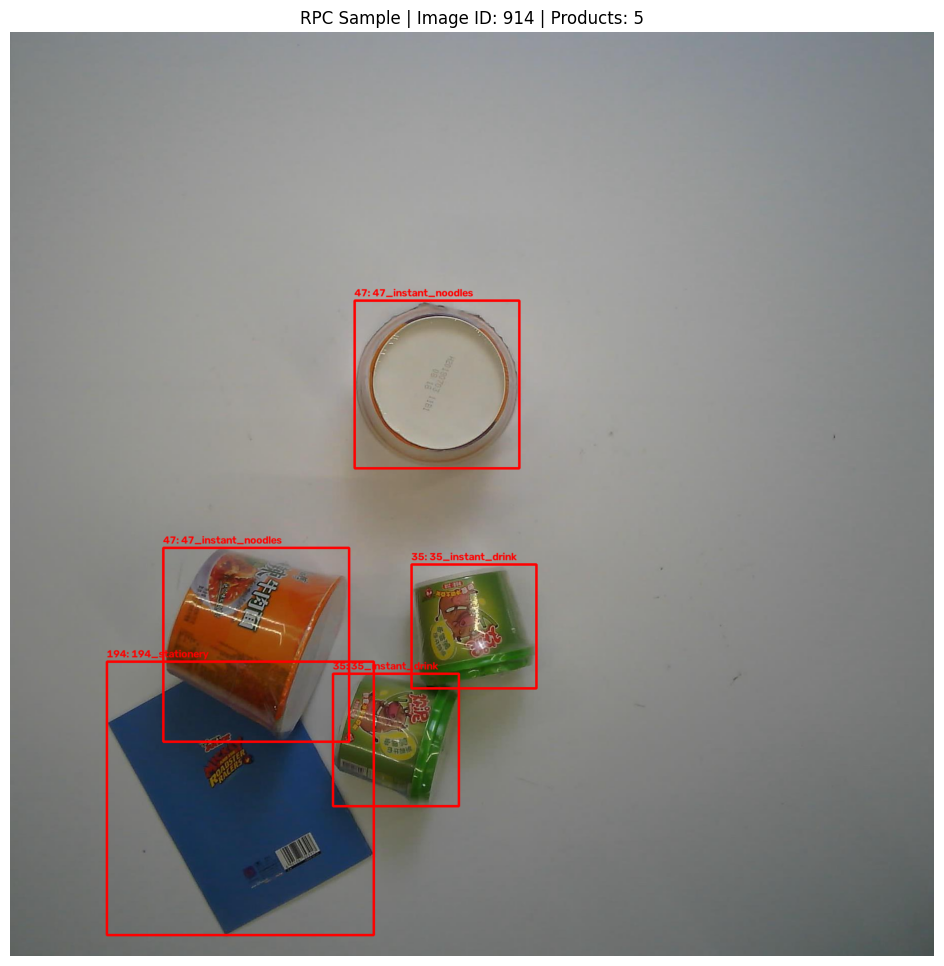

========== SAMPLE IMAGE ==========
Image ID       : 914
File name      : 20180828-11-19-11-1091.jpg
Image size     : 1835 x 1835
Products       : 5


In [13]:
import cv2
import matplotlib.pyplot as plt
import random

# Select a random image from the dataset
sample_image = random.choice(data["images"])

image_id = sample_image["id"]
file_name = sample_image["file_name"]

image_path = os.path.join(
    EXTRACTED_IMAGE_DIR,
    file_name
)

# Read image
image = cv2.imread(image_path)

# Convert BGR -> RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations belonging to this image
image_annotations = [
    annotation
    for annotation in data["annotations"]
    if annotation["image_id"] == image_id
]

# Draw bounding boxes
for annotation in image_annotations:

    x, y, width, height = annotation["bbox"]

    x1 = int(x)
    y1 = int(y)
    x2 = int(x + width)
    y2 = int(y + height)

    category_id = annotation["category_id"]
    category_name = category_names[category_id]

    # Bounding box
    cv2.rectangle(
        image_rgb,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    # Label
    label = f"{category_id}: {category_name}"

    cv2.putText(
        image_rgb,
        label,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2,
        cv2.LINE_AA
    )

# Display
plt.figure(figsize=(12, 12))
plt.imshow(image_rgb)
plt.axis("off")
plt.title(
    f"RPC Sample | Image ID: {image_id} | "
    f"Products: {len(image_annotations)}"
)
plt.show()

print("========== SAMPLE IMAGE ==========")
print("Image ID       :", image_id)
print("File name      :", file_name)
print("Image size     :", sample_image["width"], "x", sample_image["height"])
print("Products       :", len(image_annotations))

Cell 14 — Visualize multiple annotated images

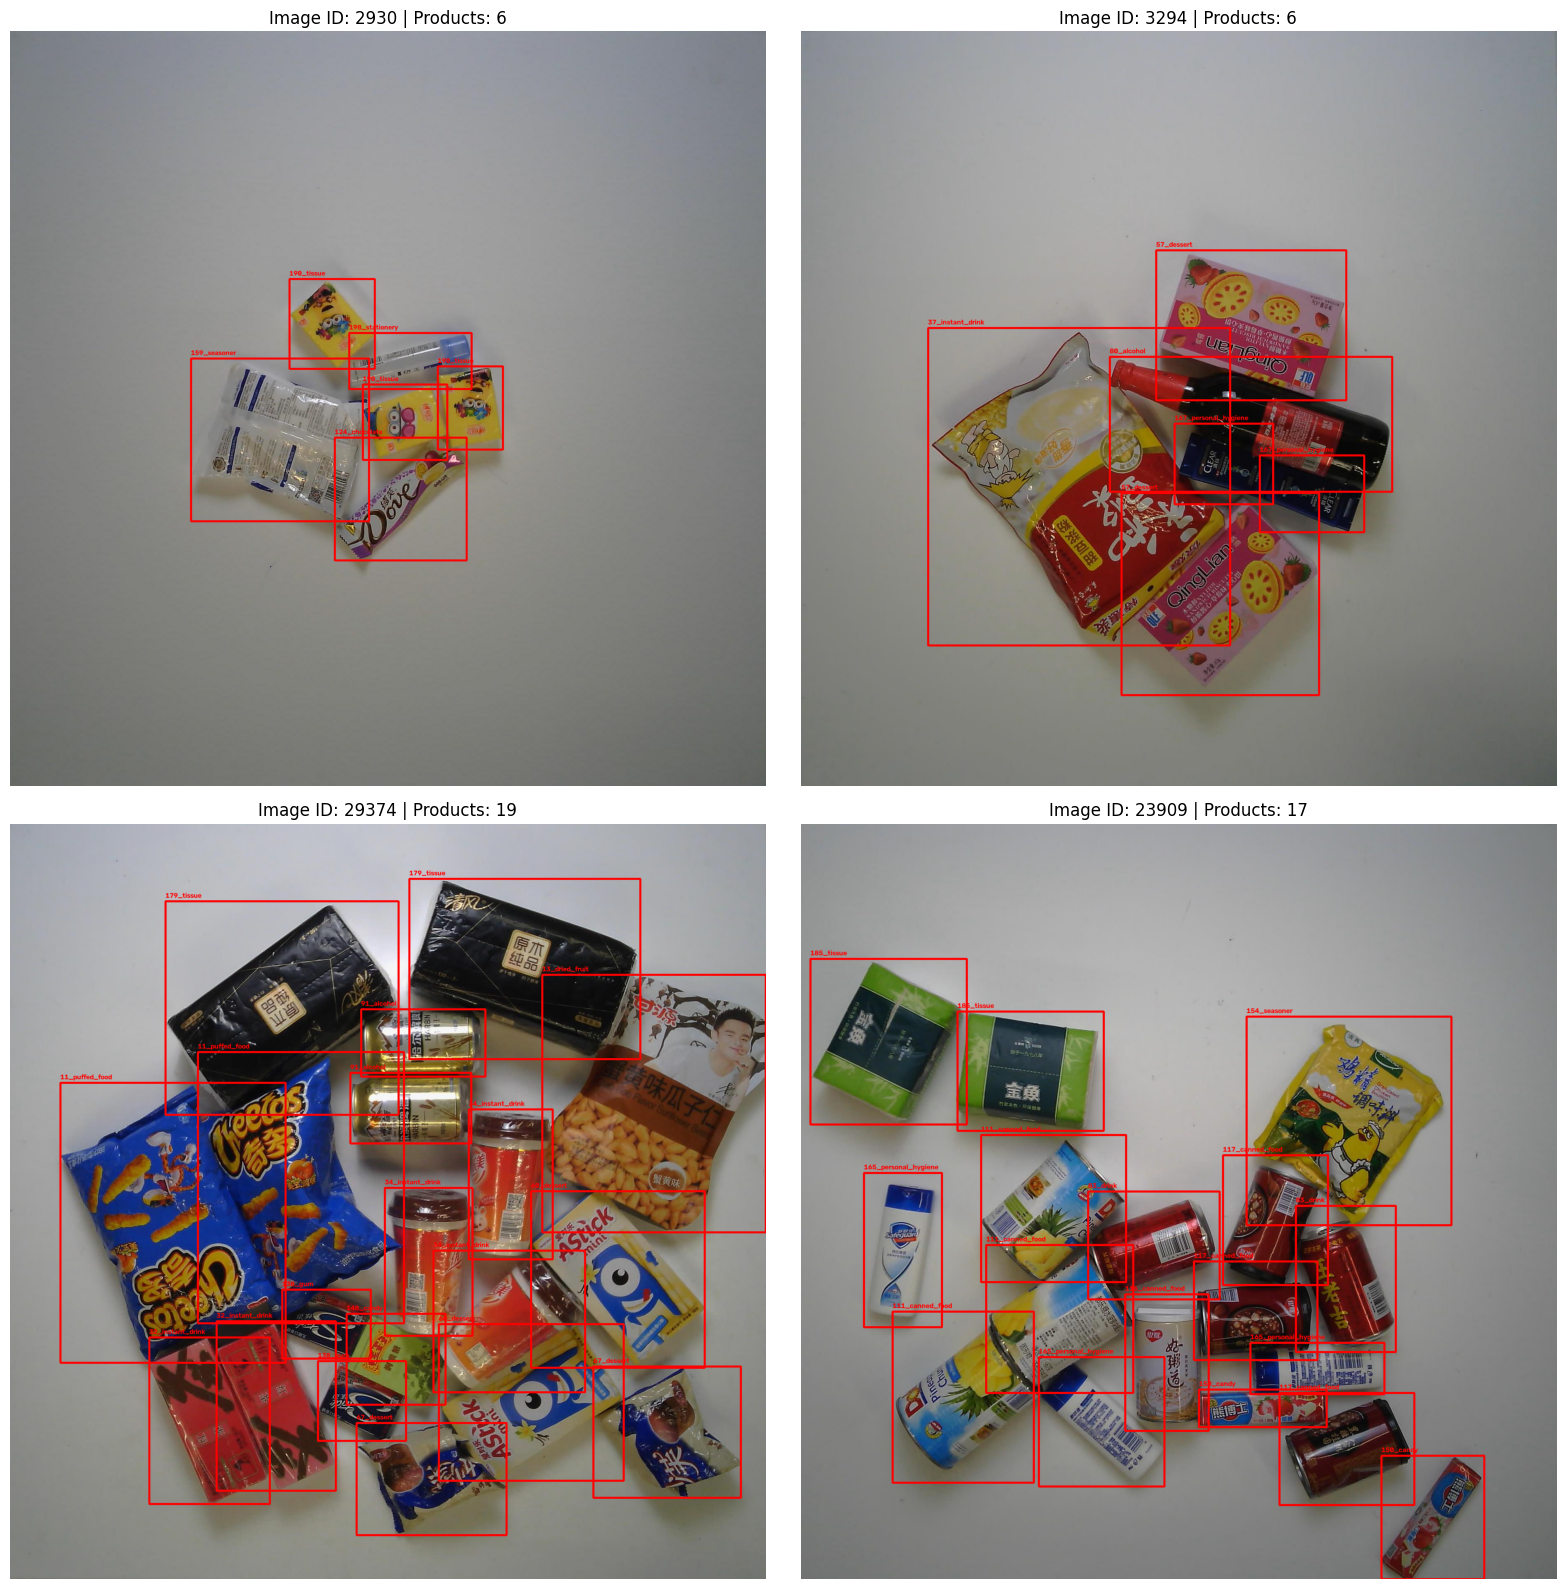

In [14]:
import cv2
import matplotlib.pyplot as plt
import random

# Select 4 random images
sample_images = random.sample(data["images"], 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, sample_image in zip(axes, sample_images):

    image_id = sample_image["id"]
    file_name = sample_image["file_name"]

    image_path = os.path.join(
        EXTRACTED_IMAGE_DIR,
        file_name
    )

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get annotations for this image
    image_annotations = [
        annotation
        for annotation in data["annotations"]
        if annotation["image_id"] == image_id
    ]

    # Draw bounding boxes
    for annotation in image_annotations:

        x, y, width, height = annotation["bbox"]

        x1 = int(x)
        y1 = int(y)
        x2 = int(x + width)
        y2 = int(y + height)

        category_id = annotation["category_id"]
        category_name = category_names[category_id]

        cv2.rectangle(
            image_rgb,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            3
        )

        cv2.putText(
            image_rgb,
            category_name,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

    ax.imshow(image_rgb)
    ax.axis("off")

    ax.set_title(
        f"Image ID: {image_id} | "
        f"Products: {len(image_annotations)}"
    )

plt.tight_layout()
plt.show()

Cell 15 — Broad-category image coverage

In [15]:
from collections import defaultdict, Counter

# Map category ID -> broad category
category_to_supercategory = {
    category["id"]: category["supercategory"]
    for category in data["categories"]
}

# Map image ID -> set of broad categories present in that image
image_supercategories = defaultdict(set)

for annotation in data["annotations"]:
    image_id = annotation["image_id"]
    category_id = annotation["category_id"]

    supercategory = category_to_supercategory[category_id]

    image_supercategories[image_id].add(supercategory)

# Count how many images contain each broad category
supercategory_image_counts = Counter()

for categories_in_image in image_supercategories.values():
    for supercategory in categories_in_image:
        supercategory_image_counts[supercategory] += 1

print("========== BROAD CATEGORY IMAGE COVERAGE ==========")
print("Total images:", len(data["images"]))
print("Total broad categories:", len(supercategory_image_counts))
print()

for category, count in sorted(
    supercategory_image_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    percentage = (count / len(data["images"])) * 100

    print(
        f"{category:<20} : "
        f"{count:>5} images "
        f"({percentage:>6.2f}%)"
    )

========== BROAD CATEGORY IMAGE COVERAGE ==========
Total images: 6000
Total broad categories: 17

tissue               :  2756 images ( 45.93%)
dessert              :  2630 images ( 43.83%)
drink                :  2493 images ( 41.55%)
seasoner             :  2107 images ( 35.12%)
puffed_food          :  1991 images ( 33.18%)
instant_noodles      :  1978 images ( 32.97%)
chocolate            :  1945 images ( 32.42%)
canned_food          :  1868 images ( 31.13%)
alcohol              :  1864 images ( 31.07%)
milk                 :  1737 images ( 28.95%)
candy                :  1709 images ( 28.48%)
personal_hygiene     :  1640 images ( 27.33%)
dried_fruit          :  1610 images ( 26.83%)
instant_drink        :  1597 images ( 26.62%)
dried_food           :  1540 images ( 25.67%)
gum                  :  1390 images ( 23.17%)
stationery           :  1034 images ( 17.23%)


Cell 16 — Verify the 200 → 17 category mapping

In [16]:
from collections import defaultdict

# Create mapping:
# SKU category ID -> SKU name + broad category
category_mapping = {}

for category in data["categories"]:
    category_mapping[category["id"]] = {
        "name": category["name"],
        "supercategory": category["supercategory"]
    }

# Group SKU classes by broad category
supercategory_skus = defaultdict(list)

for category_id, info in category_mapping.items():
    supercategory_skus[info["supercategory"]].append(
        (category_id, info["name"])
    )

print("========== SKU → BROAD CATEGORY MAPPING ==========")

print("Total SKU classes      :", len(category_mapping))
print("Total broad categories :", len(supercategory_skus))

print()

for supercategory in sorted(supercategory_skus):
    sku_list = supercategory_skus[supercategory]

    print(
        f"{supercategory:<20} : "
        f"{len(sku_list):>3} SKU classes"
    )

print("\n========== MAPPING CHECK ==========")

all_skus_mapped = all(
    info["supercategory"] in supercategory_skus
    for info in category_mapping.values()
)

print("All 200 SKU classes mapped :", all_skus_mapped)

if all_skus_mapped:
    print("✓ Every SKU class has a valid broad category.")

========== SKU → BROAD CATEGORY MAPPING ==========
Total SKU classes      : 200
Total broad categories : 17

alcohol              :  11 SKU classes
candy                :  10 SKU classes
canned_food          :  14 SKU classes
chocolate            :  12 SKU classes
dessert              :  17 SKU classes
dried_food           :   9 SKU classes
dried_fruit          :   9 SKU classes
drink                :  15 SKU classes
gum                  :   8 SKU classes
instant_drink        :  11 SKU classes
instant_noodles      :  12 SKU classes
milk                 :  11 SKU classes
personal_hygiene     :  10 SKU classes
puffed_food          :  12 SKU classes
seasoner             :  12 SKU classes
stationery           :   7 SKU classes
tissue               :  20 SKU classes

========== MAPPING CHECK ==========
All 200 SKU classes mapped : True
✓ Every SKU class has a valid broad category.


Cell 17 — Create the 17-class YOLO category mapping

In [17]:
# Create a fixed 17-class mapping
# Broad category name -> YOLO class ID

YOLO_CLASSES = sorted(supercategory_skus.keys())

SUPER_CATEGORY_TO_ID = {
    category_name: class_id
    for class_id, category_name in enumerate(YOLO_CLASSES)
}

ID_TO_SUPER_CATEGORY = {
    class_id: category_name
    for category_name, class_id in SUPER_CATEGORY_TO_ID.items()
}

print("========== YOLO CLASS MAPPING ==========")

for class_id, category_name in ID_TO_SUPER_CATEGORY.items():
    print(f"{class_id:>2} : {category_name}")

print("\n========== MAPPING SUMMARY ==========")
print("Number of YOLO classes:", len(YOLO_CLASSES))

print("\nClass IDs:")
print(list(ID_TO_SUPER_CATEGORY.keys()))

print("\nClass names:")
print(YOLO_CLASSES)

========== YOLO CLASS MAPPING ==========
 0 : alcohol
 1 : candy
 2 : canned_food
 3 : chocolate
 4 : dessert
 5 : dried_food
 6 : dried_fruit
 7 : drink
 8 : gum
 9 : instant_drink
10 : instant_noodles
11 : milk
12 : personal_hygiene
13 : puffed_food
14 : seasoner
15 : stationery
16 : tissue

========== MAPPING SUMMARY ==========
Number of YOLO classes: 17

Class IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Class names:
['alcohol', 'candy', 'canned_food', 'chocolate', 'dessert', 'dried_food', 'dried_fruit', 'drink', 'gum', 'instant_drink', 'instant_noodles', 'milk', 'personal_hygiene', 'puffed_food', 'seasoner', 'stationery', 'tissue']


Cell 18 — Create YOLO dataset folders

In [18]:
import os

# Root directory for the processed YOLO dataset
YOLO_DATASET_DIR = "/content/RPC_YOLO_17"

# Create directory structure
directories = [
    os.path.join(YOLO_DATASET_DIR, "images", "train"),
    os.path.join(YOLO_DATASET_DIR, "images", "val"),
    os.path.join(YOLO_DATASET_DIR, "images", "test"),
    os.path.join(YOLO_DATASET_DIR, "labels", "train"),
    os.path.join(YOLO_DATASET_DIR, "labels", "val"),
    os.path.join(YOLO_DATASET_DIR, "labels", "test"),
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("========== YOLO DATASET STRUCTURE ==========")
print("Root directory:", YOLO_DATASET_DIR)

for directory in directories:
    print("✓", directory)

print("\nFolder structure created successfully.")

========== YOLO DATASET STRUCTURE ==========
Root directory: /content/RPC_YOLO_17
✓ /content/RPC_YOLO_17/images/train
✓ /content/RPC_YOLO_17/images/val
✓ /content/RPC_YOLO_17/images/test
✓ /content/RPC_YOLO_17/labels/train
✓ /content/RPC_YOLO_17/labels/val
✓ /content/RPC_YOLO_17/labels/test

Folder structure created successfully.


Cell 19 — Create the train/validation/test split

In [19]:
import random
from collections import Counter

# Fixed random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Target split sizes
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Group images by difficulty level
images_by_level = {}

for image in data["images"]:
    level = image["level"]

    if level not in images_by_level:
        images_by_level[level] = []

    images_by_level[level].append(image)

# Containers for the final split
train_images = []
val_images = []
test_images = []

# Split each difficulty group separately
for level, images in images_by_level.items():

    # Shuffle a copy
    images = images.copy()
    random.shuffle(images)

    total = len(images)

    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    level_train = images[:train_count]
    level_val = images[train_count:train_count + val_count]
    level_test = images[train_count + val_count:]

    train_images.extend(level_train)
    val_images.extend(level_val)
    test_images.extend(level_test)

# Shuffle each final split
random.shuffle(train_images)
random.shuffle(val_images)
random.shuffle(test_images)

# Create image ID sets for checking overlap
train_ids = {image["id"] for image in train_images}
val_ids = {image["id"] for image in val_images}
test_ids = {image["id"] for image in test_images}

print("========== DATASET SPLIT ==========")

print("Training   :", len(train_images))
print("Validation :", len(val_images))
print("Test       :", len(test_images))
print("Total      :", len(train_images) + len(val_images) + len(test_images))

print("\n========== SPLIT PERCENTAGES ==========")

total_images = len(data["images"])

print(
    f"Training   : {len(train_images)} "
    f"({len(train_images) / total_images * 100:.2f}%)"
)

print(
    f"Validation : {len(val_images)} "
    f"({len(val_images) / total_images * 100:.2f}%)"
)

print(
    f"Test       : {len(test_images)} "
    f"({len(test_images) / total_images * 100:.2f}%)"
)

print("\n========== OVERLAP CHECK ==========")

print("Train ∩ Validation :", len(train_ids & val_ids))
print("Train ∩ Test       :", len(train_ids & test_ids))
print("Validation ∩ Test  :", len(val_ids & test_ids))

print("\n========== DIFFICULTY DISTRIBUTION ==========")

for split_name, split_images in [
    ("TRAIN", train_images),
    ("VALIDATION", val_images),
    ("TEST", test_images)
]:
    counts = Counter(
        image["level"]
        for image in split_images
    )

    print(f"\n{split_name}")

    for level in ["easy", "medium", "hard"]:
        count = counts.get(level, 0)
        percentage = count / len(split_images) * 100

        print(
            f"  {level:<7}: "
            f"{count:>4} images "
            f"({percentage:>6.2f}%)"
        )

========== DATASET SPLIT ==========
Training   : 4200
Validation : 900
Test       : 900
Total      : 6000

========== SPLIT PERCENTAGES ==========
Training   : 4200 (70.00%)
Validation : 900 (15.00%)
Test       : 900 (15.00%)

========== OVERLAP CHECK ==========
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

========== DIFFICULTY DISTRIBUTION ==========

TRAIN
  easy   : 1400 images ( 33.33%)
  medium : 1400 images ( 33.33%)
  hard   : 1400 images ( 33.33%)

VALIDATION
  easy   :  300 images ( 33.33%)
  medium :  300 images ( 33.33%)
  hard   :  300 images ( 33.33%)

TEST
  easy   :  300 images ( 33.33%)
  medium :  300 images ( 33.33%)
  hard   :  300 images ( 33.33%)


Cell 20 — Check category distribution across the splits

In [20]:
from collections import Counter

# Create image ID -> image object mapping
image_id_to_image = {
    image["id"]: image
    for image in data["images"]
}

# Create image ID -> broad categories present
image_to_supercategories = defaultdict(set)

for annotation in data["annotations"]:
    image_id = annotation["image_id"]
    category_id = annotation["category_id"]

    supercategory = category_to_supercategory[category_id]

    image_to_supercategories[image_id].add(supercategory)


def count_categories_in_split(split_images):
    counts = Counter()

    for image in split_images:
        image_id = image["id"]

        for category in image_to_supercategories[image_id]:
            counts[category] += 1

    return counts


train_category_images = count_categories_in_split(train_images)
val_category_images = count_categories_in_split(val_images)
test_category_images = count_categories_in_split(test_images)


print("========== CATEGORY IMAGE COVERAGE BY SPLIT ==========")

print(
    f"{'Category':<20}"
    f"{'Train':>8}"
    f"{'Val':>8}"
    f"{'Test':>8}"
)

print("-" * 44)

for category in YOLO_CLASSES:

    train_count = train_category_images[category]
    val_count = val_category_images[category]
    test_count = test_category_images[category]

    print(
        f"{category:<20}"
        f"{train_count:>8}"
        f"{val_count:>8}"
        f"{test_count:>8}"
    )

print("\n========== MINIMUM COVERAGE ==========")

print(
    "Minimum train images for one category :",
    min(train_category_images.values())
)

print(
    "Minimum validation images for one category :",
    min(val_category_images.values())
)

print(
    "Minimum test images for one category :",
    min(test_category_images.values())
)

========== CATEGORY IMAGE COVERAGE BY SPLIT ==========
Category               Train     Val    Test
--------------------------------------------
alcohol                 1348     261     255
candy                   1205     249     255
canned_food             1323     266     279
chocolate               1363     311     271
dessert                 1847     388     395
dried_food              1064     226     250
dried_fruit             1134     240     236
drink                   1737     367     389
gum                      975     216     199
instant_drink           1136     226     235
instant_noodles         1391     296     291
milk                    1209     264     264
personal_hygiene        1126     254     260
puffed_food             1407     285     299
seasoner                1464     322     321
stationery               698     174     162
tissue                  1919     426     411

========== MINIMUM COVERAGE ==========
Minimum train images for one category : 698
Minimu

Cell 21 — Prepare annotation lookup

In [21]:
from collections import defaultdict

# --------------------------------------------------
# 1. Image ID -> image information
# --------------------------------------------------

image_lookup = {
    image["id"]: image
    for image in data["images"]
}

# --------------------------------------------------
# 2. Group annotations by image ID
# --------------------------------------------------

annotations_by_image = defaultdict(list)

for annotation in data["annotations"]:
    image_id = annotation["image_id"]
    annotations_by_image[image_id].append(annotation)

# --------------------------------------------------
# 3. Original SKU category ID -> YOLO broad category ID
# --------------------------------------------------

sku_to_yolo_id = {}

for category in data["categories"]:

    sku_category_id = category["id"]
    broad_category = category["supercategory"]

    yolo_class_id = SUPER_CATEGORY_TO_ID[broad_category]

    sku_to_yolo_id[sku_category_id] = yolo_class_id

# --------------------------------------------------
# Verification
# --------------------------------------------------

print("========== ANNOTATION LOOKUP ==========")

print(
    "Images in lookup      :",
    len(image_lookup)
)

print(
    "Images with annotations:",
    len(annotations_by_image)
)

print(
    "Total annotations     :",
    sum(len(v) for v in annotations_by_image.values())
)

print(
    "SKU → YOLO mappings   :",
    len(sku_to_yolo_id)
)

print("\n========== CHECKS ==========")

print(
    "All images have annotations:",
    len(image_lookup) == len(annotations_by_image)
)

print(
    "All 200 SKU classes mapped:",
    len(sku_to_yolo_id) == 200
)

========== ANNOTATION LOOKUP ==========
Images in lookup      : 6000
Images with annotations: 6000
Total annotations     : 73602
SKU → YOLO mappings   : 200

========== CHECKS ==========
All images have annotations: True
All 200 SKU classes mapped: True


Cell 22 — Convert COCO bounding boxes to YOLO labels

In [22]:
import shutil
from tqdm import tqdm

# --------------------------------------------------
# Helper function: convert one split
# --------------------------------------------------

def convert_split(split_images, split_name):

    image_output_dir = os.path.join(
        YOLO_DATASET_DIR,
        "images",
        split_name
    )

    label_output_dir = os.path.join(
        YOLO_DATASET_DIR,
        "labels",
        split_name
    )

    converted_images = 0
    converted_annotations = 0

    for image_info in tqdm(
        split_images,
        desc=f"Converting {split_name}"
    ):

        image_id = image_info["id"]
        file_name = image_info["file_name"]

        # ------------------------------------------
        # Source and destination image paths
        # ------------------------------------------

        source_image = os.path.join(
            EXTRACTED_IMAGE_DIR,
            file_name
        )

        destination_image = os.path.join(
            image_output_dir,
            file_name
        )

        # Copy image
        shutil.copy2(
            source_image,
            destination_image
        )

        # ------------------------------------------
        # Image dimensions
        # ------------------------------------------

        image_width = image_info["width"]
        image_height = image_info["height"]

        # ------------------------------------------
        # Create YOLO label file
        # ------------------------------------------

        label_file_name = os.path.splitext(file_name)[0] + ".txt"

        label_path = os.path.join(
            label_output_dir,
            label_file_name
        )

        image_annotations = annotations_by_image[image_id]

        with open(label_path, "w") as label_file:

            for annotation in image_annotations:

                # Original COCO bounding box
                x, y, width, height = annotation["bbox"]

                # Convert COCO -> YOLO
                center_x = x + (width / 2)
                center_y = y + (height / 2)

                # Normalize
                center_x /= image_width
                center_y /= image_height
                width /= image_width
                height /= image_height

                # Convert original SKU category
                # to our 17-class YOLO category
                original_category_id = annotation["category_id"]

                yolo_class_id = sku_to_yolo_id[
                    original_category_id
                ]

                # Write YOLO annotation
                label_file.write(
                    f"{yolo_class_id} "
                    f"{center_x:.6f} "
                    f"{center_y:.6f} "
                    f"{width:.6f} "
                    f"{height:.6f}\n"
                )

                converted_annotations += 1

        converted_images += 1

    return converted_images, converted_annotations


# --------------------------------------------------
# Convert all three splits
# --------------------------------------------------

print("========== COCO → YOLO CONVERSION ==========\n")

train_image_count, train_annotation_count = convert_split(
    train_images,
    "train"
)

val_image_count, val_annotation_count = convert_split(
    val_images,
    "val"
)

test_image_count, test_annotation_count = convert_split(
    test_images,
    "test"
)

# --------------------------------------------------
# Final summary
# --------------------------------------------------

print("\n========== CONVERSION SUMMARY ==========")

print(
    f"Train      : {train_image_count} images, "
    f"{train_annotation_count} annotations"
)

print(
    f"Validation : {val_image_count} images, "
    f"{val_annotation_count} annotations"
)

print(
    f"Test       : {test_image_count} images, "
    f"{test_annotation_count} annotations"
)

print(
    f"\nTotal images      : "
    f"{train_image_count + val_image_count + test_image_count}"
)

print(
    f"Total annotations : "
    f"{train_annotation_count + val_annotation_count + test_annotation_count}"
)

print("\nYOLO dataset created at:")
print(YOLO_DATASET_DIR)

========== COCO → YOLO CONVERSION ==========



Converting test: 100%|██████████| 900/900 [00:00<00:00, 3294.47it/s]


========== CONVERSION SUMMARY ==========
Train      : 4200 images, 51579 annotations
Validation : 900 images, 10991 annotations
Test       : 900 images, 11032 annotations

Total images      : 6000
Total annotations : 73602

YOLO dataset created at:
/content/RPC_YOLO_17


Cell 23 — Validate YOLO labels

In [23]:
from collections import Counter

print("========== YOLO LABEL VALIDATION ==========")

total_label_files = 0
total_boxes = 0
invalid_lines = 0
invalid_class_ids = 0
invalid_coordinates = 0
empty_labels = 0

class_counts = Counter()

for split in ["train", "val", "test"]:

    label_dir = os.path.join(
        YOLO_DATASET_DIR,
        "labels",
        split
    )

    label_files = [
        file_name
        for file_name in os.listdir(label_dir)
        if file_name.endswith(".txt")
    ]

    split_boxes = 0

    for file_name in label_files:

        label_path = os.path.join(
            label_dir,
            file_name
        )

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) == 0:
            empty_labels += 1

        for line in lines:

            values = line.split()

            # YOLO format must contain 5 values
            if len(values) != 5:
                invalid_lines += 1
                continue

            class_id = int(values[0])

            center_x = float(values[1])
            center_y = float(values[2])
            width = float(values[3])
            height = float(values[4])

            # Check class ID
            if class_id < 0 or class_id >= len(YOLO_CLASSES):
                invalid_class_ids += 1

            # Check normalized coordinates
            if not (
                0 <= center_x <= 1 and
                0 <= center_y <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                invalid_coordinates += 1

            class_counts[class_id] += 1
            split_boxes += 1

    total_label_files += len(label_files)
    total_boxes += split_boxes

    print(
        f"{split.upper():<5} : "
        f"{len(label_files):>5} label files | "
        f"{split_boxes:>6} bounding boxes"
    )

print("\n========== VALIDATION SUMMARY ==========")

print("Total label files       :", total_label_files)
print("Total bounding boxes    :", total_boxes)
print("Invalid label lines    :", invalid_lines)
print("Invalid class IDs      :", invalid_class_ids)
print("Invalid coordinates    :", invalid_coordinates)
print("Empty label files      :", empty_labels)

print("\n========== CLASS ID RANGE ==========")
print("Minimum class ID:", min(class_counts.keys()))
print("Maximum class ID:", max(class_counts.keys()))

print("\n========== RESULT ==========")

if (
    invalid_lines == 0 and
    invalid_class_ids == 0 and
    invalid_coordinates == 0 and
    empty_labels == 0 and
    total_boxes == 73602
):
    print("✓ YOLO LABEL VALIDATION PASSED")
else:
    print("⚠ VALIDATION ISSUES FOUND")

========== YOLO LABEL VALIDATION ==========
TRAIN :  4200 label files |  51579 bounding boxes
VAL   :   900 label files |  10991 bounding boxes
TEST  :   900 label files |  11032 bounding boxes

========== VALIDATION SUMMARY ==========
Total label files       : 6000
Total bounding boxes    : 73602
Invalid label lines    : 0
Invalid class IDs      : 0
Invalid coordinates    : 0
Empty label files      : 0

========== CLASS ID RANGE ==========
Minimum class ID: 0
Maximum class ID: 16

========== RESULT ==========
✓ YOLO LABEL VALIDATION PASSED


Cell 24 — Create the YOLO data.yaml

In [24]:
import yaml
import os

DATA_YAML = os.path.join(
    YOLO_DATASET_DIR,
    "data.yaml"
)

data_config = {
    "path": YOLO_DATASET_DIR,

    "train": "images/train",
    "val": "images/val",
    "test": "images/test",

    "nc": len(YOLO_CLASSES),

    "names": YOLO_CLASSES
}

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.dump(
        data_config,
        f,
        sort_keys=False
    )

print("========== YOLO DATA CONFIGURATION ==========")
print("Config file:", DATA_YAML)

print("\n========== CONTENTS ==========")

with open(DATA_YAML, "r", encoding="utf-8") as f:
    print(f.read())

========== YOLO DATA CONFIGURATION ==========
Config file: /content/RPC_YOLO_17/data.yaml

========== CONTENTS ==========
path: /content/RPC_YOLO_17
train: images/train
val: images/val
test: images/test
nc: 17
names:
- alcohol
- candy
- canned_food
- chocolate
- dessert
- dried_food
- dried_fruit
- drink
- gum
- instant_drink
- instant_noodles
- milk
- personal_hygiene
- puffed_food
- seasoner
- stationery
- tissue



Cell 25 — Verify the YOLO dataset through the training framework

In [25]:
import os
import yaml

# Read the YAML configuration
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("========== DATASET CONFIGURATION CHECK ==========")

print("Dataset path :", data_config["path"])
print("Train path   :", data_config["train"])
print("Val path     :", data_config["val"])
print("Test path    :", data_config["test"])
print("Classes      :", data_config["nc"])

# Resolve paths
train_path = os.path.join(
    data_config["path"],
    data_config["train"]
)

val_path = os.path.join(
    data_config["path"],
    data_config["val"]
)

test_path = os.path.join(
    data_config["path"],
    data_config["test"]
)

print("\n========== PATH CHECK ==========")

print("Train exists :", os.path.exists(train_path))
print("Val exists   :", os.path.exists(val_path))
print("Test exists  :", os.path.exists(test_path))

# Count images
train_count = len([
    f for f in os.listdir(train_path)
    if f.lower().endswith(".jpg")
])

val_count = len([
    f for f in os.listdir(val_path)
    if f.lower().endswith(".jpg")
])

test_count = len([
    f for f in os.listdir(test_path)
    if f.lower().endswith(".jpg")
])

print("\n========== IMAGE COUNT CHECK ==========")

print("Train images :", train_count)
print("Val images   :", val_count)
print("Test images  :", test_count)

# Final check
print("\n========== RESULT ==========")

if (
    train_count == len(train_images)
    and
    val_count == len(val_images)
    and
    test_count == len(test_images)
    and
    data_config["nc"] == 17
):
    print("✓ YOLO DATASET CONFIGURATION PASSED")
else:
    print("⚠ DATASET CONFIGURATION MISMATCH")

========== DATASET CONFIGURATION CHECK ==========
Dataset path : /content/RPC_YOLO_17
Train path   : images/train
Val path     : images/val
Test path    : images/test
Classes      : 17

========== PATH CHECK ==========
Train exists : True
Val exists   : True
Test exists  : True

========== IMAGE COUNT CHECK ==========
Train images : 4200
Val images   : 900
Test images  : 900

========== RESULT ==========
✓ YOLO DATASET CONFIGURATION PASSED


Cell 26 — Check GPU and CUDA

In [26]:
import torch

print("========== GPU / CUDA INFORMATION ==========")

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("CUDA version    :", torch.version.cuda)
    print("GPU count       :", torch.cuda.device_count())

    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)

        gpu_memory = (
            torch.cuda.get_device_properties(i).total_memory
            / (1024 ** 3)
        )

        print(f"\nGPU {i}")
        print("Name            :", gpu_name)
        print(f"Memory          : {gpu_memory:.2f} GB")

else:
    print("\n⚠ CUDA GPU is not available.")
    print("Training would run on CPU.")

========== GPU / CUDA INFORMATION ==========
PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU count       : 1

GPU 0
Name            : NVIDIA A100-SXM4-40GB
Memory          : 39.49 GB


Cell 27 — Install and verify Ultralytics

In [27]:
!pip install -q -U ultralytics

import ultralytics

print("========== ULTRALYTICS SETUP ==========")
print("Ultralytics version:", ultralytics.__version__)

from ultralytics import YOLO

print("YOLO import: SUCCESS")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 10.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
========== ULTRALYTICS SETUP ==========
Ultralytics version: 8.4.156
YOLO import: SUCCESS


Cell 28 — Check available YOLO detection models

In [28]:
from ultralytics import YOLO

print("========== YOLO MODEL CHECK ==========")

models_to_check = [
    "yolo11n.pt",
    "yolo11s.pt",
    "yolo11m.pt"
]

for model_name in models_to_check:

    try:
        model = YOLO(model_name)

        print(f"✓ {model_name:<12} loaded successfully")

    except Exception as e:

        print(f"✗ {model_name:<12} failed")
        print("  Error:", str(e)[:200])

print("\nModel availability check completed.")

========== YOLO MODEL CHECK ==========
✓ yolo11n.pt   loaded successfully
✓ yolo11s.pt   loaded successfully
✓ yolo11m.pt   loaded successfully

Model availability check completed.


Cell 29 — Load YOLO11s and inspect the model

In [29]:
from ultralytics import YOLO

# Load pretrained YOLO11 Small model
MODEL_NAME = "yolo11s.pt"

model = YOLO(MODEL_NAME)

print("========== YOLO11s MODEL ==========")
print("Model:", MODEL_NAME)

print("\n========== MODEL SUMMARY ==========")
model.info()

========== YOLO11s MODEL ==========
Model: yolo11s.pt

========== MODEL SUMMARY ==========
YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.8 GFLOPs


(181, 9458752, 0, 21.8363392)

Cell 30 — Configure the first training run

In [30]:
# ==================================================
# YOLO11s TRAINING CONFIGURATION
# ==================================================

TRAIN_CONFIG = {
    "model": "yolo11s.pt",
    "data": DATA_YAML,

    # Training
    "epochs": 10,
    "imgsz": 640,
    "batch": 32,

    # Hardware
    "device": 0,
    "workers": 8,

    # Output
    "project": "/content/RPC_YOLO_Training",
    "name": "yolo11s_rpc17",

    # Reproducibility
    "seed": 42,

    # Save the best model
    "save": True,

    # Validation during training
    "val": True,
}

print("========== TRAINING CONFIGURATION ==========")

for key, value in TRAIN_CONFIG.items():
    print(f"{key:<10}: {value}")

========== TRAINING CONFIGURATION ==========
model     : yolo11s.pt
data      : /content/RPC_YOLO_17/data.yaml
epochs    : 10
imgsz     : 640
batch     : 32
device    : 0
workers   : 8
project   : /content/RPC_YOLO_Training
name      : yolo11s_rpc17
seed      : 42
save      : True
val       : True


Cell 31 — Start YOLO11s training

In [31]:
# ==================================================
# START YOLO11s TRAINING
# ==================================================

results = model.train(
    **TRAIN_CONFIG
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RPC_YOLO_17/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_rpc17, nbs=64, nms=None,

Cell 32 — Evaluate best.pt on the TEST set

In [32]:
from ultralytics import YOLO

# Load the best trained checkpoint
BEST_MODEL_PATH = (
    "/content/RPC_YOLO_Training/"
    "yolo11s_rpc17/"
    "weights/best.pt"
)

best_model = YOLO(BEST_MODEL_PATH)

print("========== TEST SET EVALUATION ==========")
print("Model:", BEST_MODEL_PATH)
print("Test data:", DATA_YAML)

test_results = best_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=32,
    device=0,
    workers=8,
    plots=True
)

print("\n========== TEST EVALUATION COMPLETED ==========")

========== TEST SET EVALUATION ==========
Model: /content/RPC_YOLO_Training/yolo11s_rpc17/weights/best.pt
Test data: /content/RPC_YOLO_17/data.yaml
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 100 layers, 9,419,379 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2362.0±634.5 MB/s, size: 205.1 KB)
val: Scanning /content/RPC_YOLO_17/labels/test... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 1.4Kit/s 0.7s
val: New cache created: /content/RPC_YOLO_17/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.8it/s 7.6s
                   all        900      11032       0.99      0.988      0.994      0.872
               alcohol        255        544      0.957      0.994      0.988      0.874
                 candy        255        552      0.993      0.959      0.992      0.826
 

Cell 33 — Run inference on one unseen test image


========== TEST IMAGE ==========
Image ID : 15912
File     : 20180905-13-11-00-226.jpg


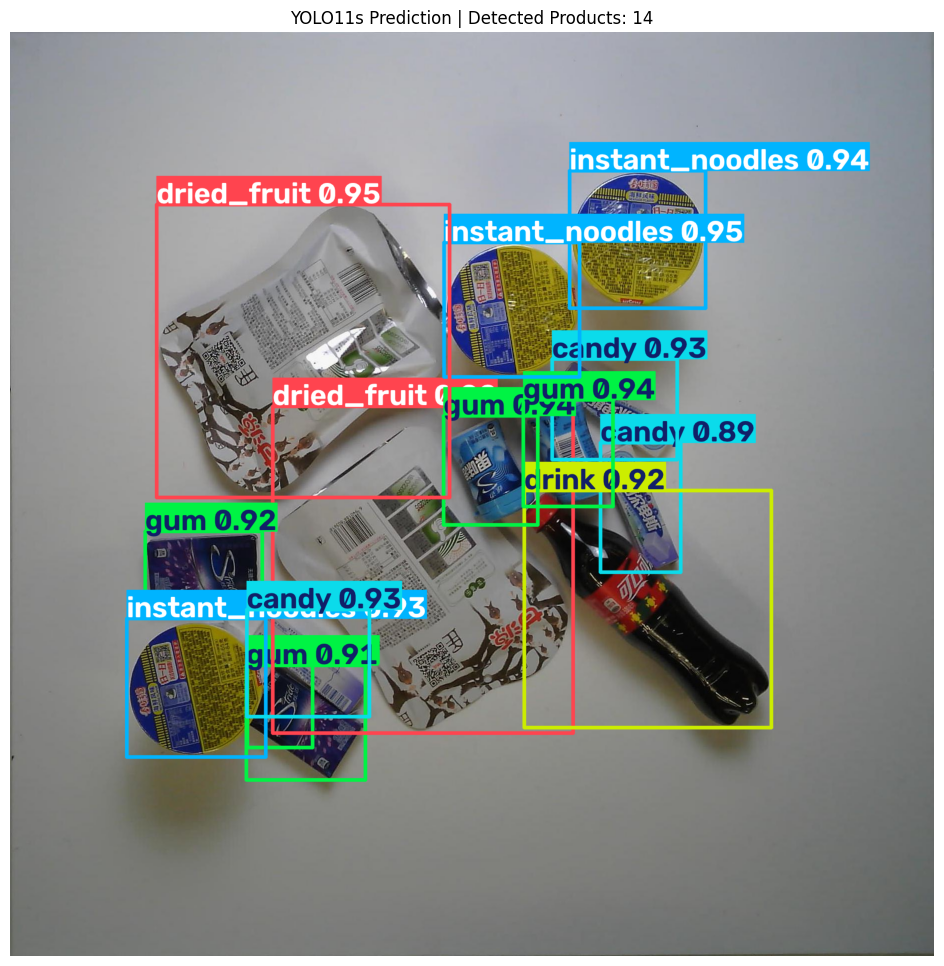


========== PREDICTION SUMMARY ==========
Detected products: 14

Detected categories:
dried_fruit          confidence = 0.951
instant_noodles      confidence = 0.950
instant_noodles      confidence = 0.942
gum                  confidence = 0.940
gum                  confidence = 0.935
candy                confidence = 0.928
candy                confidence = 0.928
instant_noodles      confidence = 0.928
gum                  confidence = 0.925
drink                confidence = 0.920
dried_fruit          confidence = 0.917
gum                  confidence = 0.908
candy                confidence = 0.888
gum                  confidence = 0.492


In [33]:
import random
import cv2
import matplotlib.pyplot as plt

# Select one image from the completely unseen test split
sample_test_image = random.choice(test_images)

test_image_id = sample_test_image["id"]
test_file_name = sample_test_image["file_name"]

test_image_path = os.path.join(
    EXTRACTED_IMAGE_DIR,
    test_file_name
)

print("========== TEST IMAGE ==========")
print("Image ID :", test_image_id)
print("File     :", test_file_name)

# Run inference
results = best_model.predict(
    source=test_image_path,
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

result = results[0]

# Convert annotated result to RGB
annotated_image = result.plot()
annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(annotated_image)
plt.axis("off")

plt.title(
    f"YOLO11s Prediction | "
    f"Detected Products: {len(result.boxes)}"
)

plt.show()

print("\n========== PREDICTION SUMMARY ==========")
print("Detected products:", len(result.boxes))

if len(result.boxes) > 0:

    predicted_classes = result.boxes.cls.cpu().numpy().astype(int)
    confidences = result.boxes.conf.cpu().numpy()

    print("\nDetected categories:")

    for class_id, confidence in zip(
        predicted_classes,
        confidences
    ):
        print(
            f"{ID_TO_SUPER_CATEGORY[class_id]:<20} "
            f"confidence = {confidence:.3f}"
        )

Cell 34 — Generate category counts and compare with ground truth

In [34]:
from collections import Counter

# --------------------------------------------------
# Confidence threshold for final counting
# --------------------------------------------------

CONF_THRESHOLD = 0.50

# --------------------------------------------------
# 1. Ground-truth category counts
# --------------------------------------------------

ground_truth_counts = Counter()

for annotation in annotations_by_image[test_image_id]:

    original_category_id = annotation["category_id"]

    yolo_class_id = sku_to_yolo_id[
        original_category_id
    ]

    category_name = ID_TO_SUPER_CATEGORY[
        yolo_class_id
    ]

    ground_truth_counts[category_name] += 1


# --------------------------------------------------
# 2. Predicted category counts
# --------------------------------------------------

predicted_counts = Counter()

for class_id, confidence in zip(
    result.boxes.cls.cpu().numpy().astype(int),
    result.boxes.conf.cpu().numpy()
):

    if confidence >= CONF_THRESHOLD:

        category_name = ID_TO_SUPER_CATEGORY[
            class_id
        ]

        predicted_counts[category_name] += 1


# --------------------------------------------------
# 3. Display comparison
# --------------------------------------------------

print("========== PRODUCT COUNT COMPARISON ==========")
print("Image ID:", test_image_id)
print("File:", test_file_name)
print("Confidence threshold:", CONF_THRESHOLD)

print("\n")
print(
    f"{'Category':<20}"
    f"{'Ground Truth':>15}"
    f"{'Predicted':>15}"
)

print("-" * 50)

for category in YOLO_CLASSES:

    ground_truth = ground_truth_counts[category]
    predicted = predicted_counts[category]

    # Only display categories present in either result
    if ground_truth > 0 or predicted > 0:

        print(
            f"{category:<20}"
            f"{ground_truth:>15}"
            f"{predicted:>15}"
        )


# --------------------------------------------------
# 4. Total counts
# --------------------------------------------------

ground_truth_total = sum(
    ground_truth_counts.values()
)

predicted_total = sum(
    predicted_counts.values()
)

print("\n========== TOTAL ==========")

print(
    "Ground-truth products :",
    ground_truth_total
)

print(
    "Predicted products    :",
    predicted_total
)

print(
    "Count difference      :",
    predicted_total - ground_truth_total
)


# --------------------------------------------------
# 5. Prediction percentage distribution
# --------------------------------------------------

print("\n========== PREDICTED CATEGORY DISTRIBUTION ==========")

if predicted_total > 0:

    for category in YOLO_CLASSES:

        count = predicted_counts[category]

        if count > 0:

            percentage = (
                count / predicted_total
            ) * 100

            print(
                f"{category:<20} : "
                f"{count:>3} products "
                f"({percentage:>6.2f}%)"
            )

========== PRODUCT COUNT COMPARISON ==========
Image ID: 15912
File: 20180905-13-11-00-226.jpg
Confidence threshold: 0.5


Category               Ground Truth      Predicted
--------------------------------------------------
candy                             3              3
dried_fruit                       2              2
drink                             1              1
gum                               4              4
instant_noodles                   3              3

========== TOTAL ==========
Ground-truth products : 13
Predicted products    : 13
Count difference      : 0

========== PREDICTED CATEGORY DISTRIBUTION ==========
candy                :   3 products ( 23.08%)
dried_fruit          :   2 products ( 15.38%)
drink                :   1 products (  7.69%)
gum                  :   4 products ( 30.77%)
instant_noodles      :   3 products ( 23.08%)


Cell 35 — Test counting across multiple unseen images

In [35]:
from collections import Counter
import random

# --------------------------------------------------
# Evaluation settings
# --------------------------------------------------

CONF_THRESHOLD = 0.50
NUM_SAMPLES = 20

random.seed(42)

# Select 20 different unseen test images
evaluation_images = random.sample(
    test_images,
    NUM_SAMPLES
)

# --------------------------------------------------
# Storage for evaluation results
# --------------------------------------------------

total_ground_truth = 0
total_predicted = 0
exact_count_matches = 0

category_gt_total = Counter()
category_pred_total = Counter()

print("========== MULTI-IMAGE COUNTING EVALUATION ==========")
print("Images evaluated:", NUM_SAMPLES)
print("Confidence threshold:", CONF_THRESHOLD)
print()

# --------------------------------------------------
# Evaluate each image
# --------------------------------------------------

for index, image_info in enumerate(
    evaluation_images,
    start=1
):

    image_id = image_info["id"]
    file_name = image_info["file_name"]

    image_path = os.path.join(
        EXTRACTED_IMAGE_DIR,
        file_name
    )

    # Ground truth
    gt_counts = Counter()

    for annotation in annotations_by_image[image_id]:

        original_category_id = annotation["category_id"]

        yolo_class_id = sku_to_yolo_id[
            original_category_id
        ]

        category_name = ID_TO_SUPER_CATEGORY[
            yolo_class_id
        ]

        gt_counts[category_name] += 1

    # Prediction
    prediction_results = best_model.predict(
        source=image_path,
        imgsz=640,
        conf=CONF_THRESHOLD,
        device=0,
        verbose=False
    )

    prediction = prediction_results[0]

    pred_counts = Counter()

    for class_id in (
        prediction.boxes.cls.cpu()
        .numpy()
        .astype(int)
    ):

        category_name = ID_TO_SUPER_CATEGORY[
            class_id
        ]

        pred_counts[category_name] += 1

    # Totals
    gt_total = sum(gt_counts.values())
    pred_total = sum(pred_counts.values())

    total_ground_truth += gt_total
    total_predicted += pred_total

    if gt_total == pred_total:
        exact_count_matches += 1

    # Category totals
    category_gt_total.update(gt_counts)
    category_pred_total.update(pred_counts)

    print(
        f"{index:>2}. "
        f"Image {image_id:<6} | "
        f"GT: {gt_total:>2} | "
        f"Pred: {pred_total:>2} | "
        f"Difference: {pred_total - gt_total:+d}"
    )

# --------------------------------------------------
# Overall summary
# --------------------------------------------------

count_accuracy = (
    exact_count_matches / NUM_SAMPLES
) * 100

print("\n========== COUNTING SUMMARY ==========")

print(
    "Images evaluated          :",
    NUM_SAMPLES
)

print(
    "Total ground-truth objects:",
    total_ground_truth
)

print(
    "Total predicted objects   :",
    total_predicted
)

print(
    "Exact image count matches :",
    exact_count_matches,
    f"/ {NUM_SAMPLES}"
)

print(
    "Exact count-match rate    :",
    f"{count_accuracy:.2f}%"
)

print(
    "Overall count difference  :",
    total_predicted - total_ground_truth
)

print("\n========== CATEGORY TOTALS ==========")

print(
    f"{'Category':<20}"
    f"{'Ground Truth':>15}"
    f"{'Predicted':>15}"
)

print("-" * 50)

for category in YOLO_CLASSES:

    gt = category_gt_total[category]
    pred = category_pred_total[category]

    if gt > 0 or pred > 0:

        print(
            f"{category:<20}"
            f"{gt:>15}"
            f"{pred:>15}"
        )

========== MULTI-IMAGE COUNTING EVALUATION ==========
Images evaluated: 20
Confidence threshold: 0.5

 1. Image 26584  | GT: 18 | Pred: 18 | Difference: +0
 2. Image 14118  | GT: 12 | Pred: 12 | Difference: +0
 3. Image 23913  | GT: 17 | Pred: 17 | Difference: +0
 4. Image 28600  | GT: 19 | Pred: 20 | Difference: +1
 5. Image 1188   | GT:  5 | Pred:  5 | Difference: +0
 6. Image 827    | GT:  5 | Pred:  5 | Difference: +0
 7. Image 12966  | GT: 11 | Pred: 11 | Difference: +0
 8. Image 29131  | GT: 19 | Pred: 19 | Difference: +0
 9. Image 20831  | GT: 15 | Pred: 15 | Difference: +0
10. Image 24223  | GT: 17 | Pred: 17 | Difference: +0
11. Image 24912  | GT: 17 | Pred: 17 | Difference: +0
12. Image 2422   | GT:  6 | Pred:  6 | Difference: +0
13. Image 15897  | GT: 13 | Pred: 13 | Difference: +0
14. Image 5558   | GT:  7 | Pred:  7 | Difference: +0
15. Image 23842  | GT: 16 | Pred: 16 | Difference: +0
16. Image 16866  | GT: 13 | Pred: 13 | Difference: +0
17. Image 23973  | GT: 17 | Pred: 

Cell 36 — Reset inference and evaluate 900 images one-by-one

In [38]:
import os
import gc
import torch
from collections import Counter
from ultralytics import YOLO

# ==================================================
# 1. RELEASE PREVIOUS INFERENCE OBJECTS
# ==================================================

print("========== CLEARING GPU MEMORY ==========")

# Remove objects from previous failed prediction attempts
try:
    del test_predictions
except:
    pass

try:
    del best_model
except:
    pass

try:
    del results
except:
    pass

try:
    del result
except:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / (1024**3):.2f} GB"
)

print(
    f"GPU memory reserved : "
    f"{torch.cuda.memory_reserved() / (1024**3):.2f} GB"
)

# ==================================================
# 2. LOAD A FRESH MODEL
# ==================================================

BEST_MODEL_PATH = (
    "/content/RPC_YOLO_Training/"
    "yolo11s_rpc17/"
    "weights/best.pt"
)

counting_model = YOLO(BEST_MODEL_PATH)

print("\nFresh model loaded.")

# ==================================================
# 3. EVALUATION SETTINGS
# ==================================================

CONF_THRESHOLD = 0.50

total_gt = 0
total_pred = 0

exact_matches = 0

absolute_count_errors = []
signed_count_errors = []

category_gt_total = Counter()
category_pred_total = Counter()

# ==================================================
# 4. PROCESS ONE IMAGE AT A TIME
# ==================================================

print("\n========== FULL TEST-SET COUNTING ==========")
print("Test images:", len(test_images))
print("Confidence threshold:", CONF_THRESHOLD)
print("Inference mode: one image at a time")
print()

for index, image_info in enumerate(
    test_images,
    start=1
):

    image_id = image_info["id"]
    file_name = image_info["file_name"]

    image_path = os.path.join(
        EXTRACTED_IMAGE_DIR,
        file_name
    )

    # ----------------------------------------------
    # Ground truth
    # ----------------------------------------------

    gt_counts = Counter()

    for annotation in annotations_by_image[image_id]:

        original_category_id = annotation["category_id"]

        yolo_class_id = sku_to_yolo_id[
            original_category_id
        ]

        category_name = ID_TO_SUPER_CATEGORY[
            yolo_class_id
        ]

        gt_counts[category_name] += 1

    gt_total = sum(gt_counts.values())

    # ----------------------------------------------
    # Prediction
    # ----------------------------------------------

    with torch.inference_mode():

        prediction_result = counting_model.predict(
            source=image_path,
            imgsz=640,
            conf=CONF_THRESHOLD,
            device=0,
            verbose=False
        )[0]

    pred_counts = Counter()

    if len(prediction_result.boxes) > 0:

        predicted_class_ids = (
            prediction_result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        for class_id in predicted_class_ids:

            category_name = ID_TO_SUPER_CATEGORY[
                class_id
            ]

            pred_counts[category_name] += 1

    pred_total = sum(pred_counts.values())

    # ----------------------------------------------
    # Count comparison
    # ----------------------------------------------

    count_error = pred_total - gt_total

    total_gt += gt_total
    total_pred += pred_total

    absolute_count_errors.append(
        abs(count_error)
    )

    signed_count_errors.append(
        count_error
    )

    if count_error == 0:
        exact_matches += 1

    # ----------------------------------------------
    # Category totals
    # ----------------------------------------------

    category_gt_total.update(gt_counts)
    category_pred_total.update(pred_counts)

    # ----------------------------------------------
    # Release result from memory
    # ----------------------------------------------

    del prediction_result

    # ----------------------------------------------
    # Progress
    # ----------------------------------------------

    if index % 50 == 0:

        print(
            f"Processed {index}/{len(test_images)} "
            f"images..."
        )

        gc.collect()
        torch.cuda.empty_cache()

# ==================================================
# 5. CALCULATE FINAL METRICS
# ==================================================

num_images = len(test_images)

exact_match_rate = (
    exact_matches / num_images
) * 100

mean_absolute_count_error = (
    sum(absolute_count_errors)
    / num_images
)

mean_signed_count_error = (
    sum(signed_count_errors)
    / num_images
)

total_count_difference = (
    total_pred - total_gt
)

# ==================================================
# 6. FINAL RESULTS
# ==================================================

print("\n========== FINAL COUNTING RESULTS ==========")

print(
    "Test images evaluated       :",
    num_images
)

print(
    "Ground-truth products       :",
    total_gt
)

print(
    "Predicted products          :",
    total_pred
)

print(
    "Exact image count matches   :",
    exact_matches,
    f"/ {num_images}"
)

print(
    "Exact count-match rate      :",
    f"{exact_match_rate:.2f}%"
)

print(
    "Mean absolute count error   :",
    f"{mean_absolute_count_error:.3f}"
)

print(
    "Mean signed count error     :",
    f"{mean_signed_count_error:.3f}"
)

print(
    "Overall count difference    :",
    total_count_difference
)

# ==================================================
# 7. CATEGORY-LEVEL COUNT RESULTS
# ==================================================

print("\n========== CATEGORY COUNT TOTALS ==========")

print(
    f"{'Category':<20}"
    f"{'Ground Truth':>15}"
    f"{'Predicted':>15}"
    f"{'Difference':>15}"
)

print("-" * 65)

for category in YOLO_CLASSES:

    gt = category_gt_total[category]
    pred = category_pred_total[category]

    difference = pred - gt

    print(
        f"{category:<20}"
        f"{gt:>15}"
        f"{pred:>15}"
        f"{difference:>15}"
    )

# ==================================================
# 8. FINAL GPU CLEANUP
# ==================================================

gc.collect()
torch.cuda.empty_cache()

print("\n✓ FULL TEST-SET COUNTING EVALUATION COMPLETED")

========== CLEARING GPU MEMORY ==========
GPU memory allocated: 7.78 GB
GPU memory reserved : 15.36 GB

Fresh model loaded.

========== FULL TEST-SET COUNTING ==========
Test images: 900
Confidence threshold: 0.5
Inference mode: one image at a time

Processed 50/900 images...
Processed 100/900 images...
Processed 150/900 images...
Processed 200/900 images...
Processed 250/900 images...
Processed 300/900 images...
Processed 350/900 images...
Processed 400/900 images...
Processed 450/900 images...
Processed 500/900 images...
Processed 550/900 images...
Processed 600/900 images...
Processed 650/900 images...
Processed 700/900 images...
Processed 750/900 images...
Processed 800/900 images...
Processed 850/900 images...
Processed 900/900 images...

========== FINAL COUNTING RESULTS ==========
Test images evaluated       : 900
Ground-truth products       : 11032
Predicted products          : 11039
Exact image count matches   : 828 / 900
Exact count-match rate      : 92.00%
Mean absolute coun